In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [5]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['start_year']>1991].copy()
rainfall_events_all_df['length'] = rainfall_events_all_df['times'].apply(len)

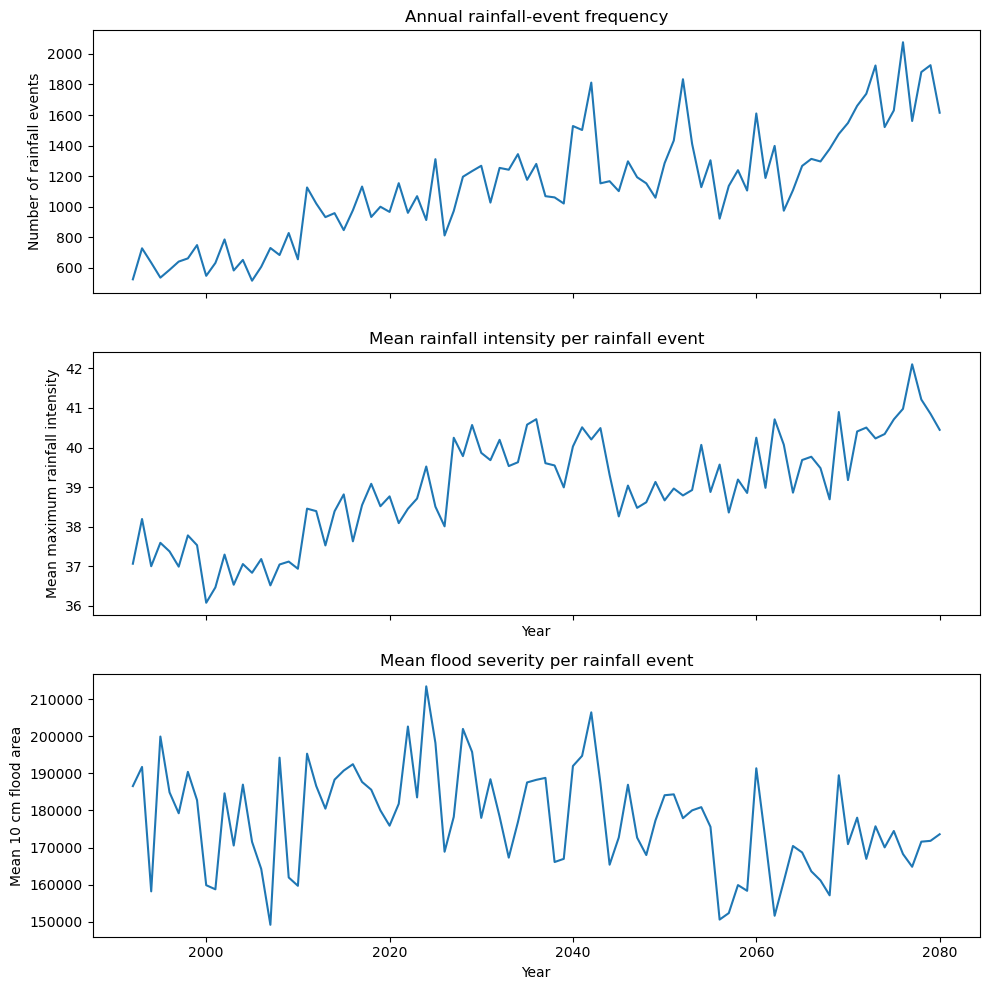

In [39]:
annual_mean_flood_severity = (rainfall_events_all_df.groupby("start_year", observed=True)["10cm_volume"].mean())
annual_mean_rainfall_severity = (rainfall_events_all_df.groupby("start_year", observed=True)["max_precip"].mean())
annual_counts = (rainfall_events_all_df.groupby(["start_year"],observed=True)).size()
annual_severity = (rainfall_events_all_df.groupby(["start_year"], observed=True)["10cm_area"].sum())

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Event frequency
axes[0].plot(annual_counts.index, annual_counts.values)
axes[0].set_ylabel("Number of rainfall events")
axes[0].set_title("Annual rainfall-event frequency")

# Severity per event
axes[1].plot(annual_mean_rainfall_severity.index, annual_mean_rainfall_severity.values)
axes[1].set_ylabel("Mean maximum rainfall intensity")
axes[1].set_xlabel("Year")
axes[1].set_title("Mean rainfall intensity per rainfall event")

# Severity per event
axes[2].plot(annual_mean_flood_severity.index, annual_mean_flood_severity.values)
axes[2].set_ylabel("Mean 10 cm flood area")
axes[2].set_xlabel("Year")
axes[2].set_title("Mean flood severity per rainfall event")

plt.tight_layout()
plt.show()

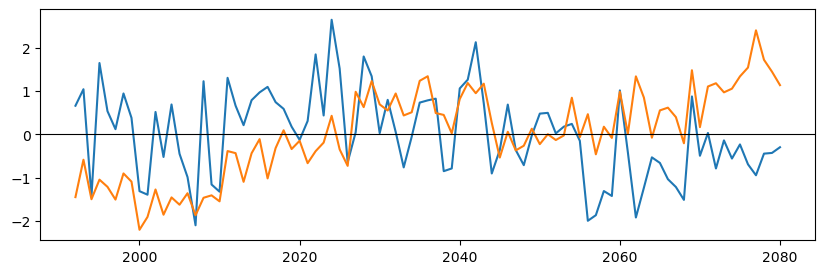

In [7]:
fig, ax =plt.subplots(figsize=(10, 3))
df=rainfall_events_all_df
annual_mean_flood_severity = (df.groupby("start_year", observed=True)["10cm_volume"].mean())
annual_mean_rainfall_intensity= (df.groupby("start_year", observed=True)["max_precip"].mean())
annual_counts = (df.groupby(["start_year"],observed=True)).size()
annual_severity = (df.groupby(["start_year"], observed=True)["10cm_area"].sum())

intensity_z = zscore(annual_mean_rainfall_intensity)
severity_z = zscore(annual_mean_flood_severity)

ax.plot(annual_mean_flood_severity.index, severity_z,label="Mean flood severity")
ax.plot(annual_mean_rainfall_intensity.index,intensity_z,label="Mean rainfall severity")
ax.axhline(0, color="black", linewidth=0.8)

In [28]:
df_A = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] >= 3]
df_B = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=1) & (rainfall_events_all_df['hc_at_peak'] < 3)]
df_C = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.6) & (rainfall_events_all_df['hc_at_peak'] < 1)]
df_D = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.3) & (rainfall_events_all_df['hc_at_peak'] < 0.6)]
df_E = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] < 0.3]

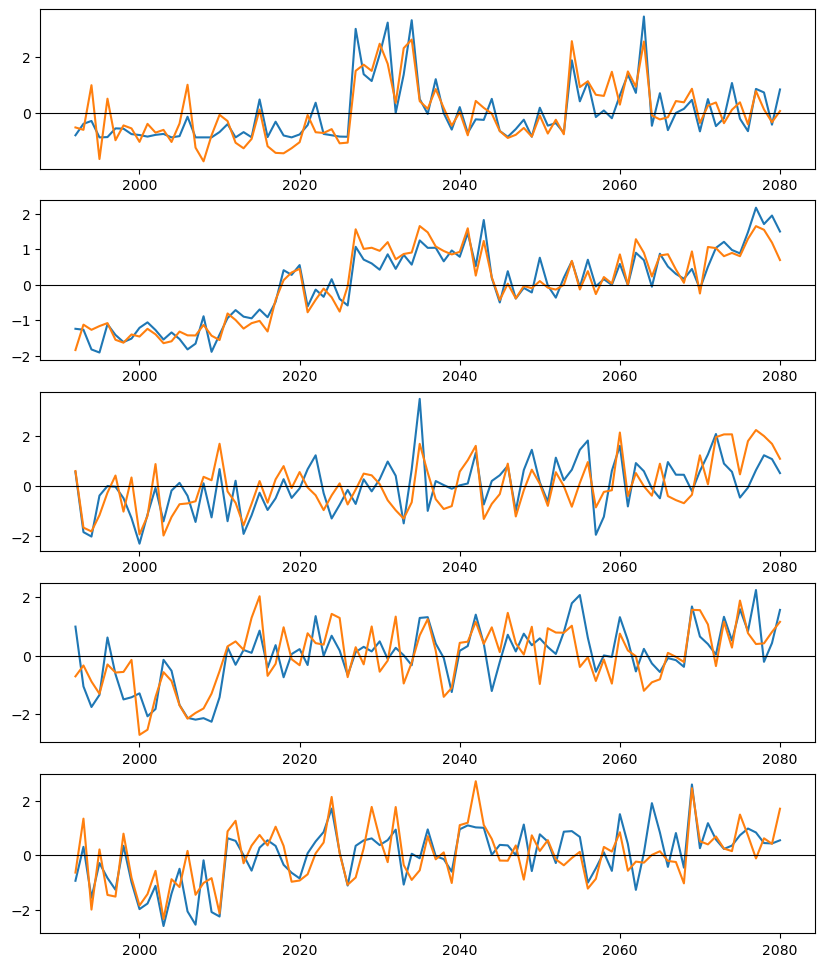

In [31]:
df_A = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] >= 3]
df_B = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=1) & (rainfall_events_all_df['hc_at_peak'] < 3)]
df_C = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.6) & (rainfall_events_all_df['hc_at_peak'] < 1)]
df_D = rainfall_events_all_df[(rainfall_events_all_df['hc_at_peak'] >=0.3) & (rainfall_events_all_df['hc_at_peak'] < 0.6)]
df_E = rainfall_events_all_df[rainfall_events_all_df['hc_at_peak'] < 0.3]

from scipy.stats import zscore

fig, axs =plt.subplots(nrows=5, figsize=(10, 12))
for num, df in enumerate([df_A, df_B, df_C, df_D, df_E]):

    annual_mean_flood_severity = (df.groupby("start_year", observed=True)["10cm_volume"].mean())
    annual_mean_rainfall_intensity= (df.groupby("start_year", observed=True)["max_precip"].mean())
    annual_counts = (df.groupby(["start_year"],observed=True)).size()

    intensity_z = zscore(annual_mean_rainfall_intensity)
    severity_z = zscore(annual_mean_flood_severity)
    
    axs[num].plot(annual_mean_flood_severity.index, severity_z,label="Mean flood severity")
    axs[num].plot(annual_mean_rainfall_intensity.index,intensity_z,label="Mean rainfall severity")
    axs[num].axhline(0, color="black", linewidth=0.8)
    
#     axs[num].set_title()


In [25]:
rainfall_events_all_df['hc_at_peak'].max()

np.float64(7.573807716369629)

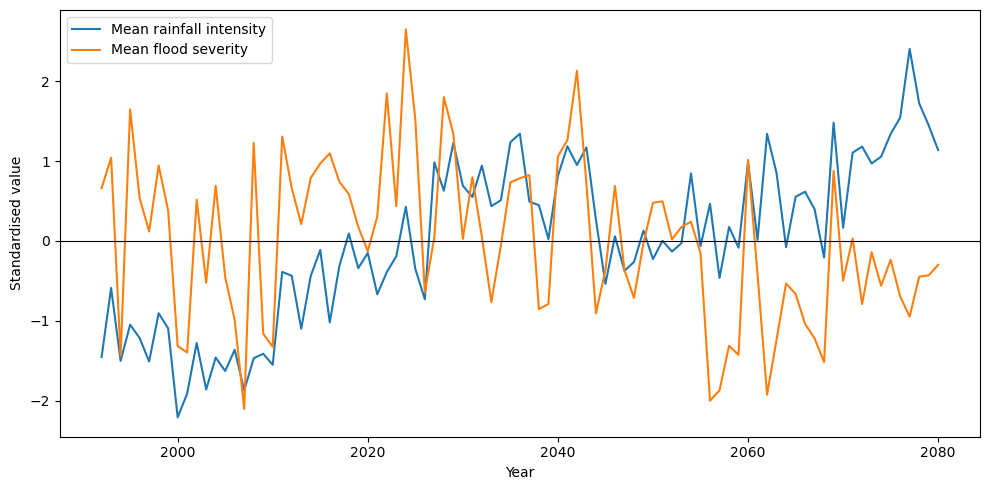

In [42]:
from scipy.stats import zscore

intensity_z = zscore(annual_mean_rainfall_severity)
severity_z = zscore(annual_mean_flood_severity)

plt.figure(figsize=(10, 5))

plt.plot(
    annual_mean_rainfall_severity.index,
    intensity_z,
    label="Mean rainfall intensity"
)

plt.plot(
    annual_mean_flood_severity.index,
    severity_z,
    label="Mean flood severity"
)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("Year")
plt.ylabel("Standardised value")
plt.legend()

plt.tight_layout()
plt.show()

A: r = 0.558, p = 2.14e-208, n = 2543
B: r = 0.608, p = 0, n = 27269
C: r = 0.481, p = 0, n = 6657
D: r = 0.474, p = 0, n = 36127
E: r = 0.474, p = 0, n = 28795


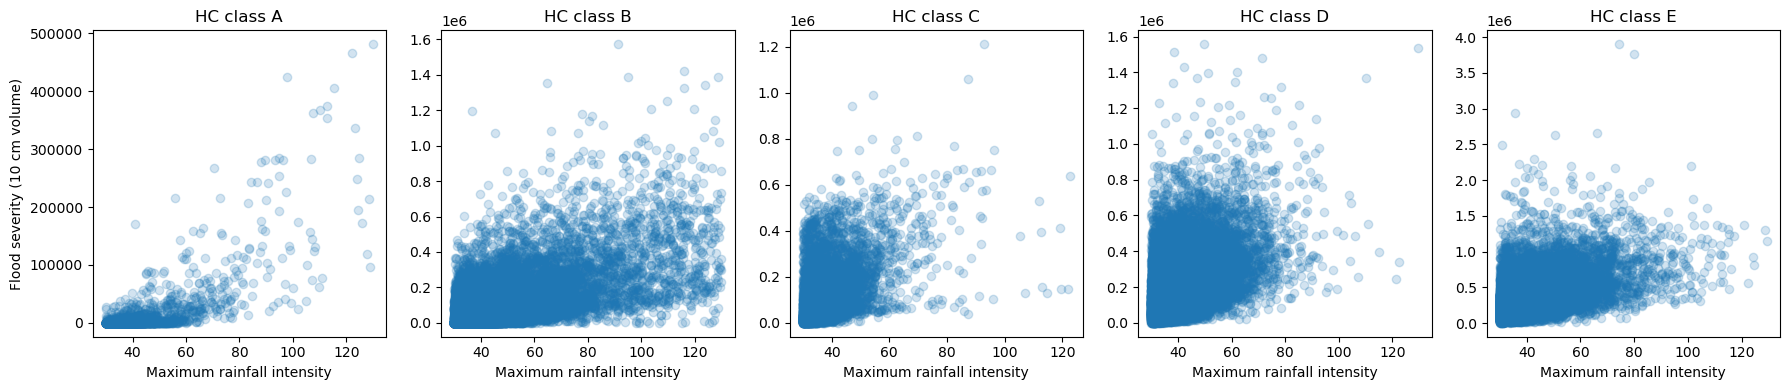

In [34]:
from scipy.stats import spearmanr

dfs = {
    "A": df_A,
    "B": df_B,
    "C": df_C,
    "D": df_D,
    "E": df_E
}

for cls, df in dfs.items():

    tmp = df[["max_precip", "10cm_volume"]].dropna()

    r, p = spearmanr(
        tmp["max_precip"],
        tmp["10cm_volume"]
    )

    print(f"{cls}: r = {r:.3f}, p = {p:.3g}, n = {len(tmp)}")
    
fig, axs = plt.subplots(1, 5, figsize=(18, 4), sharey=False)

for ax, (cls, df) in zip(axs, dfs.items()):

    tmp = df[["max_precip", "10cm_volume"]].dropna()

    ax.scatter(
        tmp["max_precip"],
        tmp["10cm_volume"],
        alpha=0.2
    )

    ax.set_title(f"HC class {cls}")
    ax.set_xlabel("Maximum rainfall intensity")

axs[0].set_ylabel("Flood severity (10 cm volume)")

plt.tight_layout()
plt.show()

In [49]:
rainfall_events_all_df['HC_status'] = pd.cut(rainfall_events_all_df['hc_at_peak'],
    bins=[-float('inf'), 0.15, 0.5, 1.1, 3, float('inf')],labels=['E', 'D', 'C', 'B', 'A'], right=False, include_lowest=True)

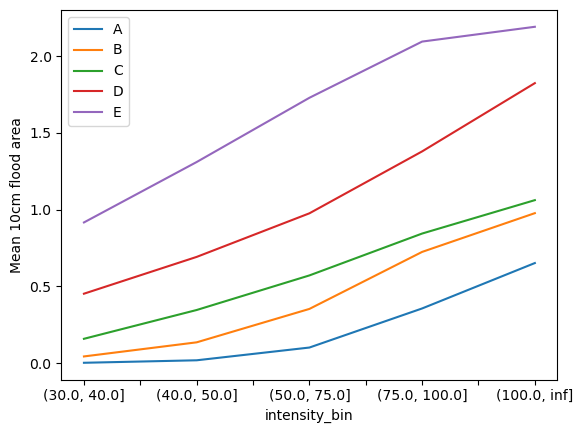

In [58]:
rainfall_events_all_df["intensity_bin"] = pd.cut(rainfall_events_all_df["max_precip"],
    bins=[0, 10, 20, 30, 40, 50, 75, 100, np.inf])

summary = (rainfall_events_all_df
    .groupby(["HC_status", "intensity_bin"], observed=True)["10cm_area"]
    .mean())


fig,ax=plt.subplots()
summary['A'].plot(ax=ax, label='A')
summary['B'].plot(ax=ax,  label='B')
summary['C'].plot(ax=ax,  label='C')
summary['D'].plot(ax=ax,  label='D')
summary['E'].plot(ax=ax,  label='E')
ax.set_ylabel("Mean 10cm flood area")
ax.legend()

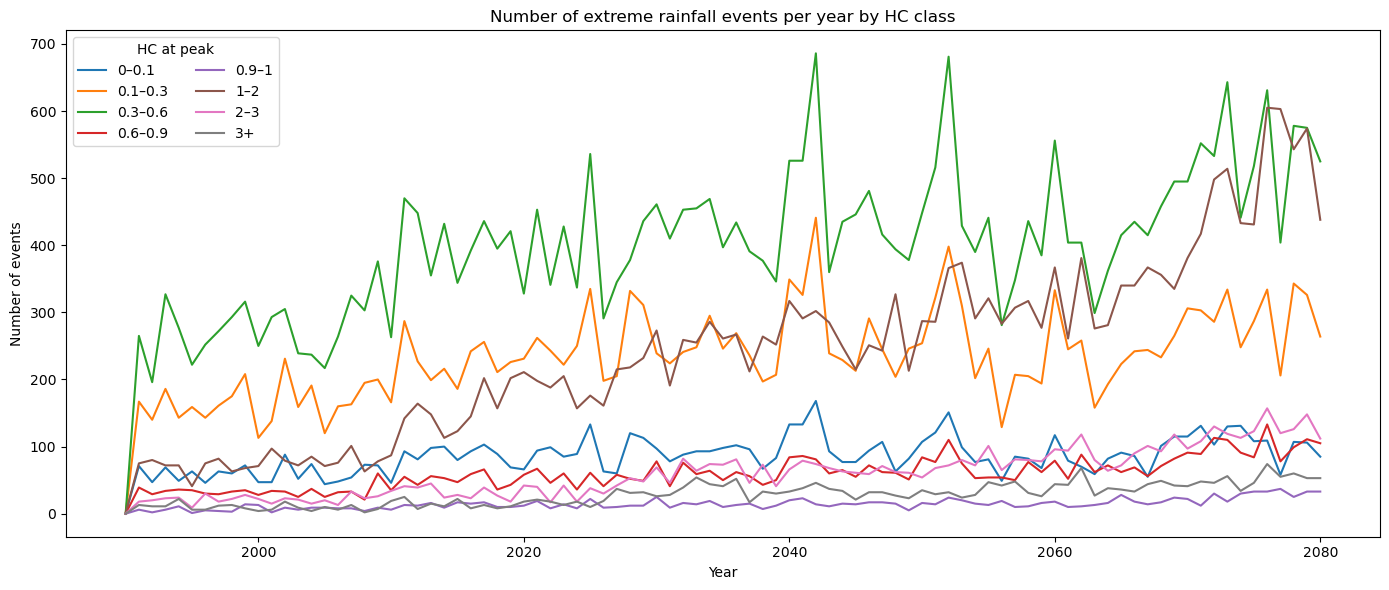

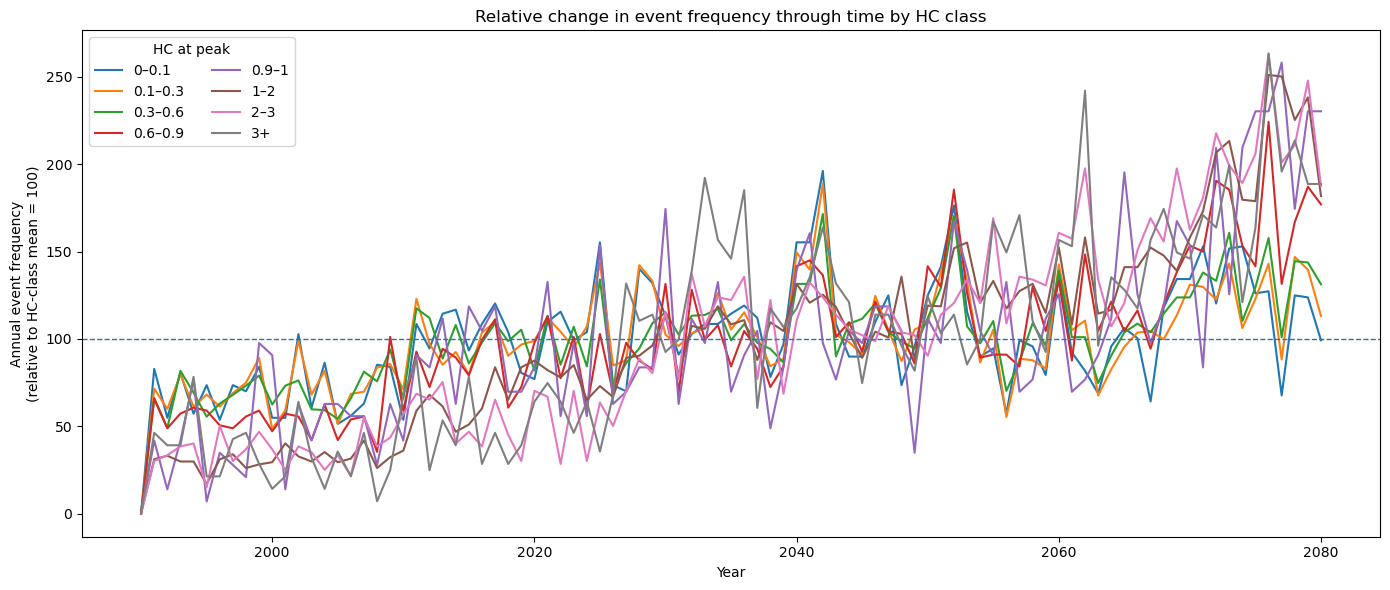

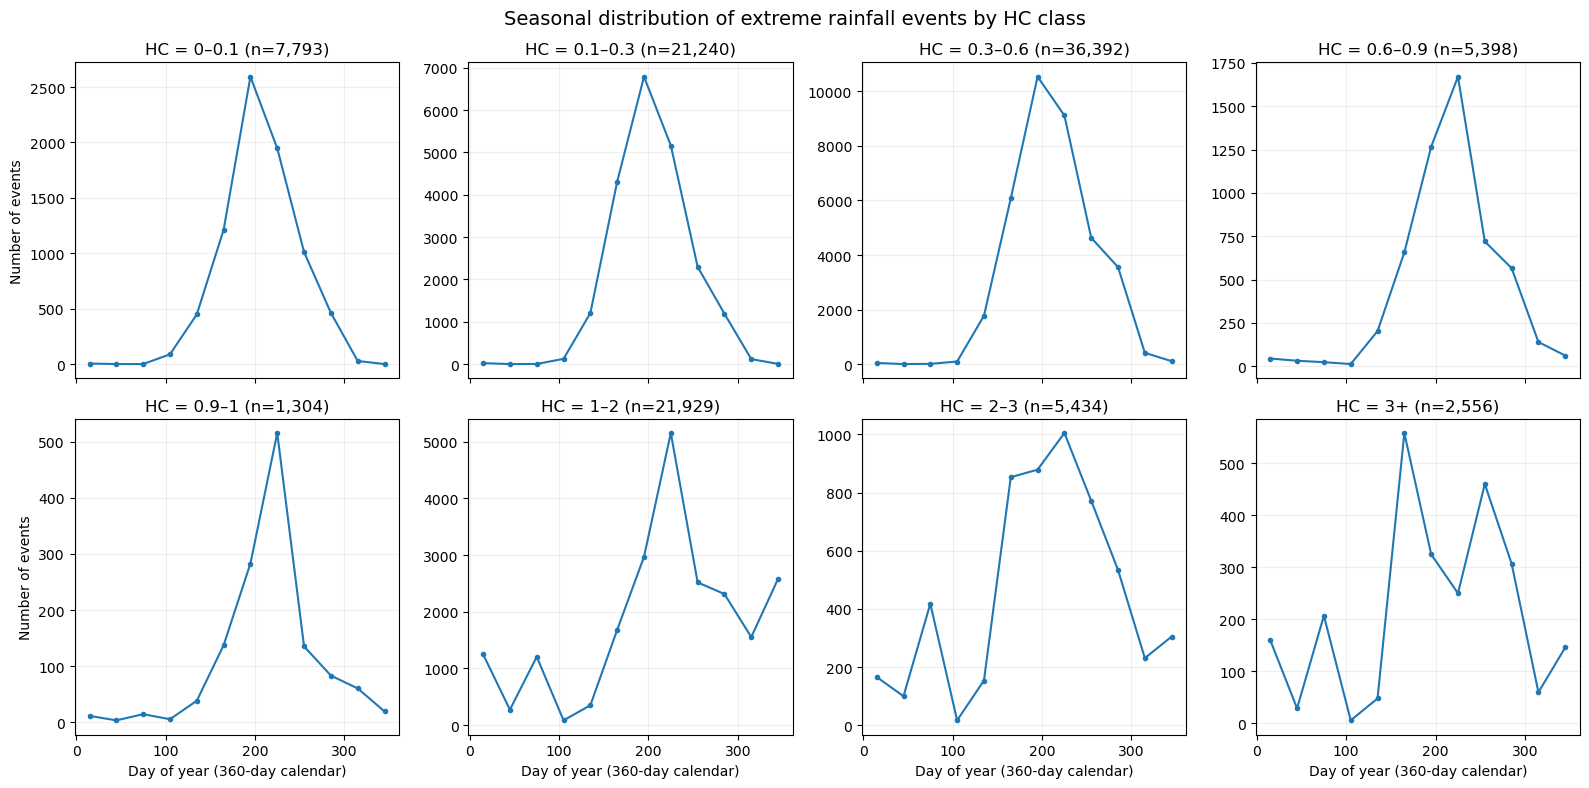

In [3]:
df = rainfall_events_all_df.copy()

# =========================================================
# 1. Define the same HC classes used in your analysis
# =========================================================

hc_bins = [-np.inf, 0.1, 0.3, 0.6, 0.9, 1, 2, 3, np.inf]

hc_labels = ["0–0.1","0.1–0.3","0.3–0.6","0.6–0.9","0.9–1","1–2","2–3","3+"]

df["HC_class"] = pd.cut(df["hc_at_peak"],bins=hc_bins,labels=hc_labels,right=False)

# Continuous representation of event time
df["event_time"] = (df["start_year"] + (df["day_360"] - 1) / 360)

# Remove rows without required information
df = df.dropna(subset=["start_year", "day_360", "HC_class"])

# =========================================================
# 2. Annual event counts
# =========================================================

annual_counts = (df.groupby(["start_year", "HC_class"],observed=True)
    .size()
    .unstack(fill_value=0))

# Make sure all HC classes are present as columns
annual_counts = annual_counts.reindex(columns=hc_labels,fill_value=0)

# =========================================================
# PLOT 1
# Raw number of events per year
# =========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(annual_counts.index,annual_counts[hc],label=hc,linewidth=1.5)

ax.set_xlabel("Year")
ax.set_ylabel("Number of events")
ax.set_title("Number of extreme rainfall events per year by HC class")
ax.legend(title="HC at peak", ncol=2)

plt.tight_layout()
plt.show()

# =========================================================
# 3. Normalised annual event frequency
# =========================================================

# Calculate each class's mean annual event count
# and express each year relative to that mean.
#
# 100 = typical annual frequency for that HC class
# >100 = more events than typical
# <100 = fewer events than typical

annual_index = (annual_counts / annual_counts.mean(axis=0) * 100)

# =========================================================
# PLOT 2
# Relative change through time
# =========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(annual_index.index,annual_index[hc],label=hc,linewidth=1.5)

ax.axhline(100,linestyle="--",linewidth=1)

ax.set_xlabel("Year")
ax.set_ylabel("Annual event frequency\n(relative to HC-class mean = 100)")
ax.set_title("Relative change in event frequency through time by HC class")

ax.legend(title="HC at peak", ncol=2)

plt.tight_layout()
plt.show()


# =========================================================
# 4. Seasonal event frequency
# =========================================================

# Bin the 360-day year into 30-day periods

bin_width = 30
bin_edges = np.arange(0,360 + bin_width,bin_width)
bin_centers = (bin_edges[:-1]+ bin_width / 2)
df["season_bin"] = pd.cut(df["day_360"],bins=bin_edges,labels=bin_centers,include_lowest=True)

# Count events by HC class and seasonal bin
seasonal_counts = (df.groupby(["HC_class", "season_bin"], observed=True)
    .size()
    .unstack(fill_value=0))
seasonal_counts = seasonal_counts.reindex(index=hc_labels, columns=bin_centers, fill_value=0)


# =========================================================
# PLOT 3
# Seasonal distribution by HC class
# =========================================================

fig, axes = plt.subplots(2,4,figsize=(16, 8),sharex=True,sharey=False)

axes = axes.flatten()

for ax, hc in zip(axes, hc_labels):
    values = seasonal_counts.loc[hc]
    ax.plot(bin_centers,values,marker="o",markersize=3,linewidth=1.5)
    ax.set_title(f"HC = {hc} (n={len(df[df['HC_class'] == hc]):,})")
    ax.grid(alpha=0.2)

for ax in axes[4:]:
    ax.set_xlabel("Day of year (360-day calendar)")

for ax in axes[::4]:
    ax.set_ylabel("Number of events")

fig.suptitle("Seasonal distribution of extreme rainfall events by HC class", fontsize=14)

plt.tight_layout()
plt.show()

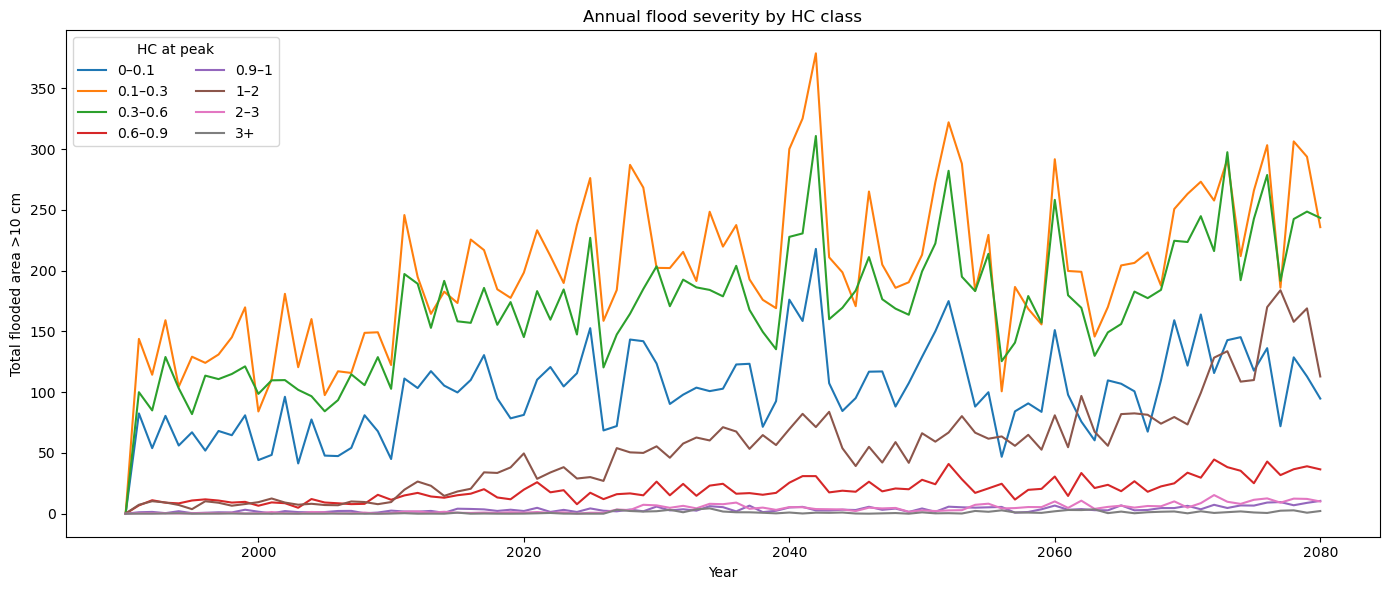

In [15]:

# =========================================================
# 1. Define HC classes
# =========================================================

hc_bins = [-np.inf, 0.1, 0.3, 0.6, 0.9, 1, 2, 3, np.inf]

hc_labels = [
    "0–0.1",
    "0.1–0.3",
    "0.3–0.6",
    "0.6–0.9",
    "0.9–1",
    "1–2",
    "2–3",
    "3+"
]

df["HC_class"] = pd.cut(
    df["hc_at_peak"],
    bins=hc_bins,
    labels=hc_labels,
    right=False
)

# Remove rows without required information
df = df.dropna(
    subset=["start_year", "day_360", "HC_class", "10cm_area"]
)

# =========================================================
# 2. Annual flood severity
# =========================================================

# Total flooded area produced by events in each year
annual_severity = (
    df.groupby(
        ["start_year", "HC_class"],
        observed=True
    )["10cm_area"]
    .sum()
    .unstack(fill_value=0)
)

annual_severity = annual_severity.reindex(
    columns=hc_labels,
    fill_value=0
)

# =========================================================
# PLOT 1
# Total annual flooded area
# =========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        annual_severity.index,
        annual_severity[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")
ax.set_ylabel("Total flooded area >10 cm")
ax.set_title(
    "Annual flood severity by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

plt.tight_layout()
plt.show()

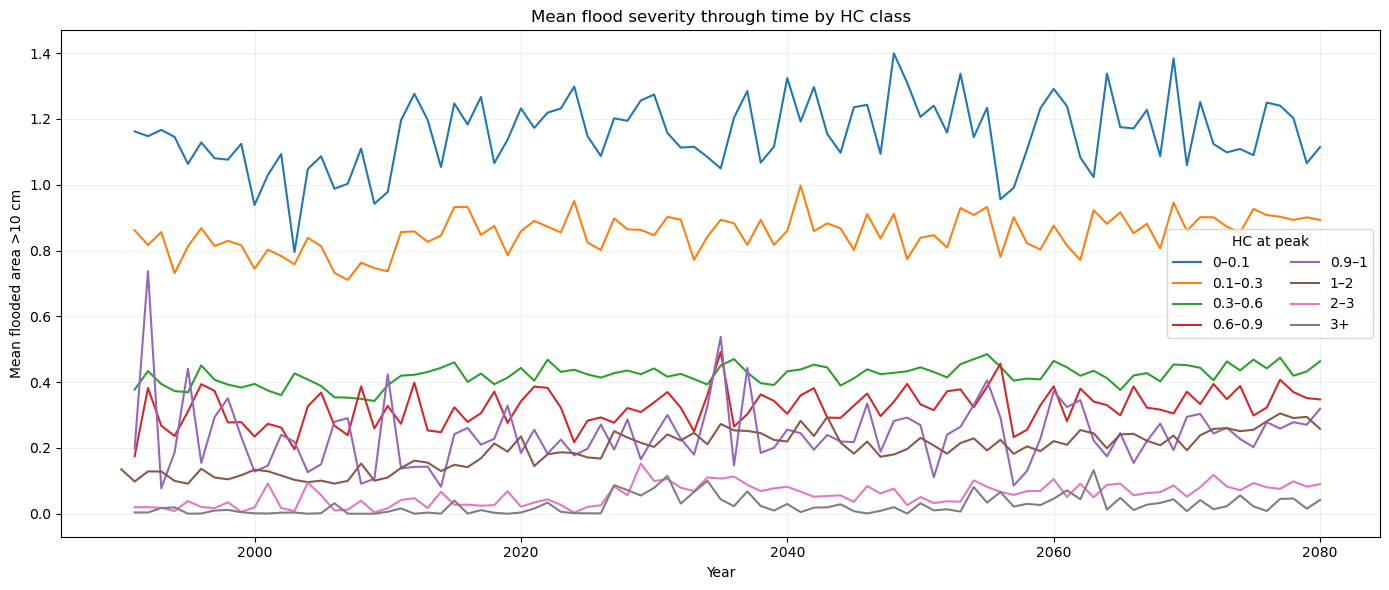

In [37]:
annual_mean_severity = (
    df.groupby(
        ["start_year", "HC_class"],
        observed=True
    )["10cm_area"]
    .mean()
    .unstack()
)

annual_mean_severity = annual_mean_severity.reindex(
    columns=hc_labels
)


fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        annual_mean_severity.index,
        annual_mean_severity[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")
ax.set_ylabel("Mean flooded area >10 cm")
ax.set_title(
    "Mean flood severity through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

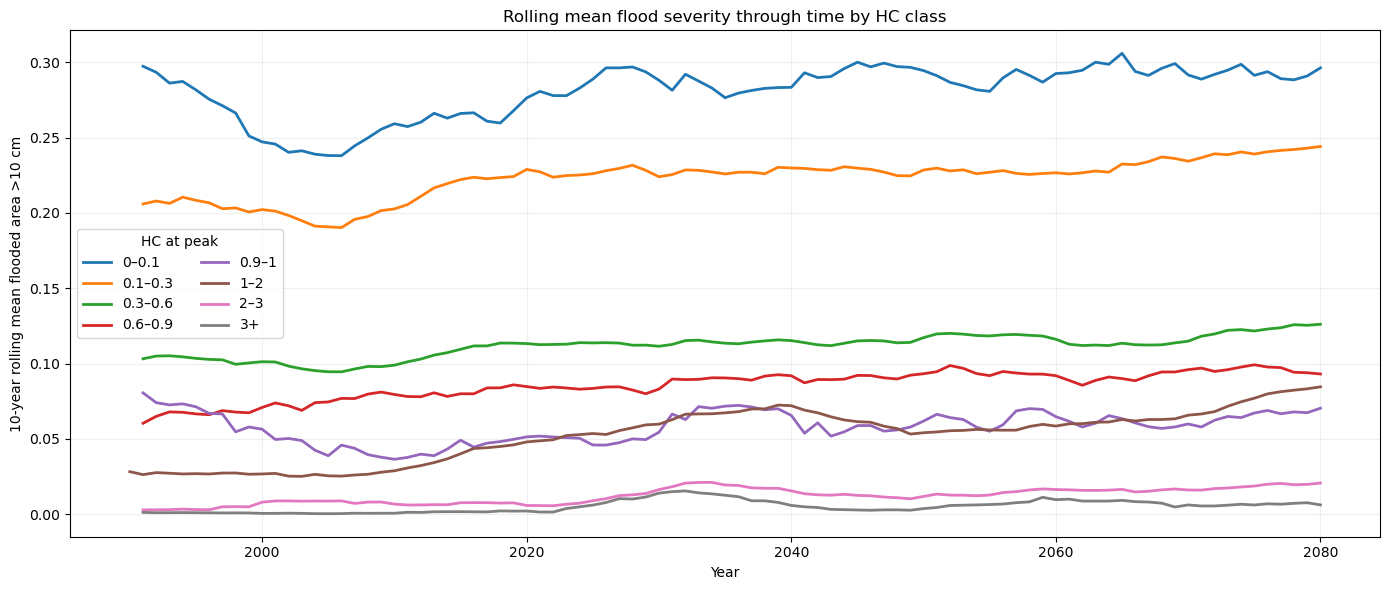

In [34]:
# 10-year rolling mean
rolling_severity = annual_mean_severity.rolling(
    window=10,
    center=True,
    min_periods=5
).mean()

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        rolling_severity.index,
        rolling_severity[hc],
        label=hc,
        linewidth=2
    )

ax.set_xlabel("Year")
ax.set_ylabel("10-year rolling mean flooded area >10 cm")
ax.set_title(
    "Rolling mean flood severity through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

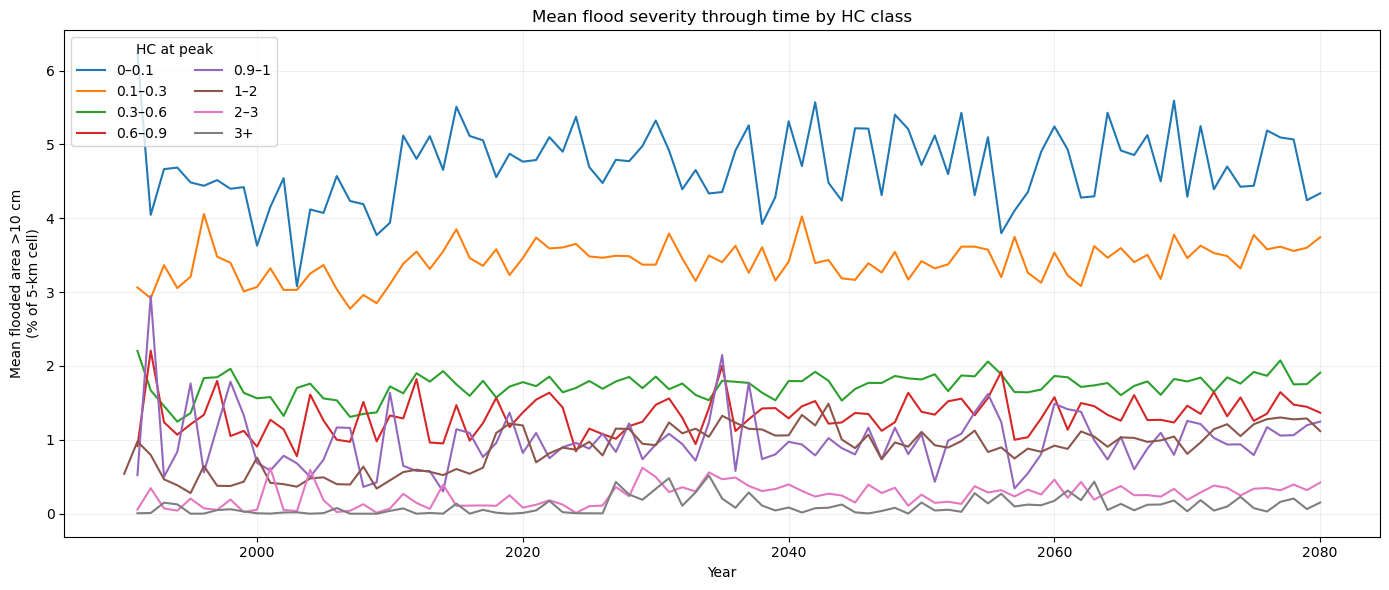

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = rainfall_events_all_df.copy()

# =========================================================
# 1. HC classes
# =========================================================

hc_bins = [-np.inf, 0.1, 0.3, 0.6, 0.9, 1, 2, 3, np.inf]

hc_labels = [
    "0–0.1",
    "0.1–0.3",
    "0.3–0.6",
    "0.6–0.9",
    "0.9–1",
    "1–2",
    "2–3",
    "3+"
]

df["HC_class"] = pd.cut(
    df["hc_at_peak"],
    bins=hc_bins,
    labels=hc_labels,
    right=False
)

# =========================================================
# 2. Flood severity for each event
# =========================================================

CELL_AREA = 25  # km²

df["flood_percent"] = (
    df["10cm_area"] / CELL_AREA * 100
)

# =========================================================
# 3. Mean severity for each cell in each year
# =========================================================

cell_year_severity = (
    df.groupby(
        ["start_year", "HC_class", "event_num"],
        observed=True
    )["flood_percent"]
    .mean()
    .reset_index()
)

# =========================================================
# 4. Average equally across cells within each HC class
# =========================================================

annual_severity = (
    cell_year_severity
    .groupby(
        ["start_year", "HC_class"],
        observed=True
    )["flood_percent"]
    .mean()
    .unstack()
)

annual_severity = annual_severity.reindex(
    columns=hc_labels
)

# =========================================================
# 5. Plot
# =========================================================

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:

    ax.plot(
        annual_severity.index,
        annual_severity[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")

ax.set_ylabel(
    "Mean flooded area >10 cm\n"
    "(% of 5-km cell)"
)

ax.set_title(
    "Mean flood severity through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

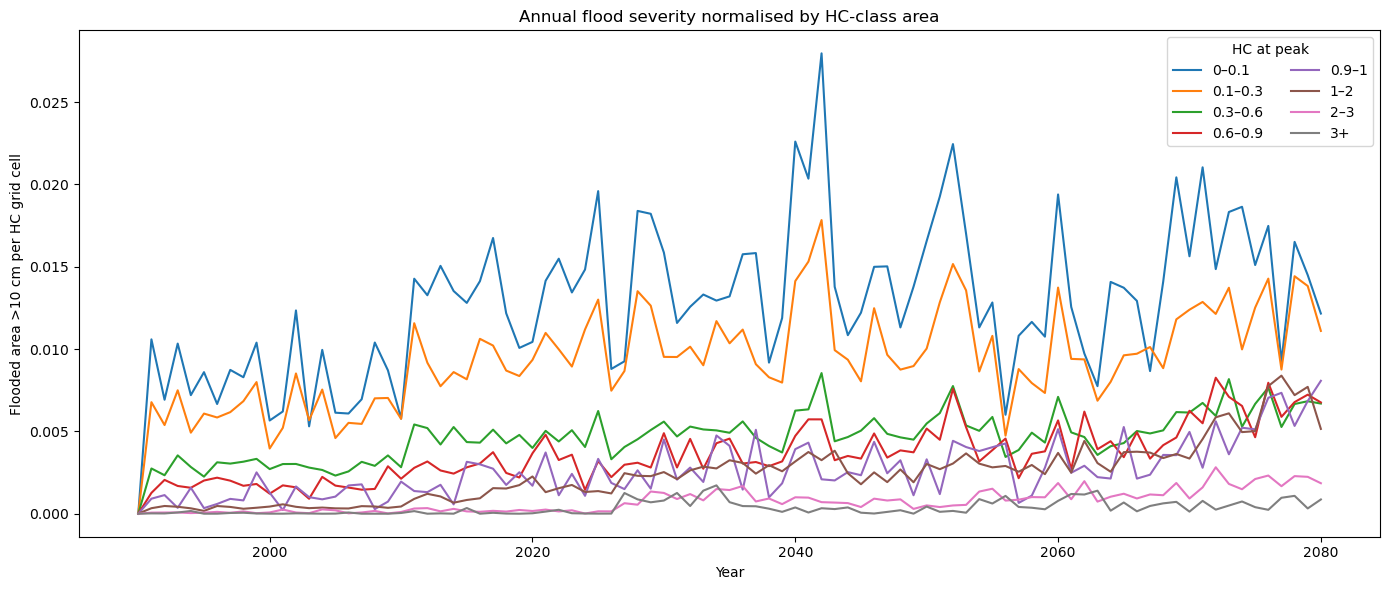

In [22]:
# Number of grid cells in each HC class
n_cells = df.groupby("HC_class", observed=True).size()

# Annual total flooded area
annual_severity = (
    df.groupby(
        ["start_year", "HC_class"],
        observed=True
    )["10cm_area"]
    .sum()
    .unstack(fill_value=0)
)

annual_severity = annual_severity.reindex(
    columns=hc_labels,
    fill_value=0
)

# Normalise by number of cells in each HC class
annual_severity_per_cell = annual_severity.div(
    n_cells,
    axis="columns"
)

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        annual_severity_per_cell.index,
        annual_severity_per_cell[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")
ax.set_ylabel("Flooded area >10 cm per HC grid cell")
ax.set_title(
    "Annual flood severity normalised by HC-class area"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

plt.tight_layout()
plt.show()

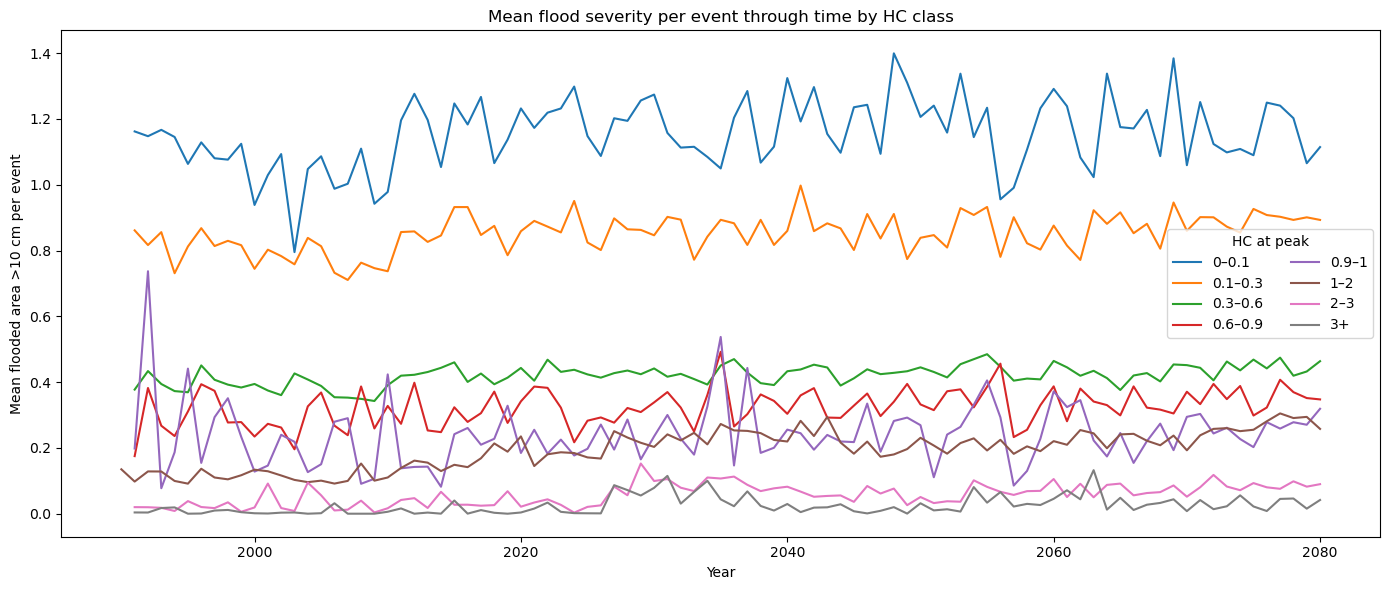

In [17]:
annual_mean_severity = (
    df.groupby(
        ["start_year", "HC_class"],
        observed=True
    )["10cm_area"]
    .mean()
    .unstack()
)

annual_mean_severity = annual_mean_severity.reindex(
    columns=hc_labels
)

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        annual_mean_severity.index,
        annual_mean_severity[hc],
        label=hc,
        linewidth=1.5
    )

ax.set_xlabel("Year")
ax.set_ylabel("Mean flooded area >10 cm per event")
ax.set_title(
    "Mean flood severity per event through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

plt.tight_layout()
plt.show()

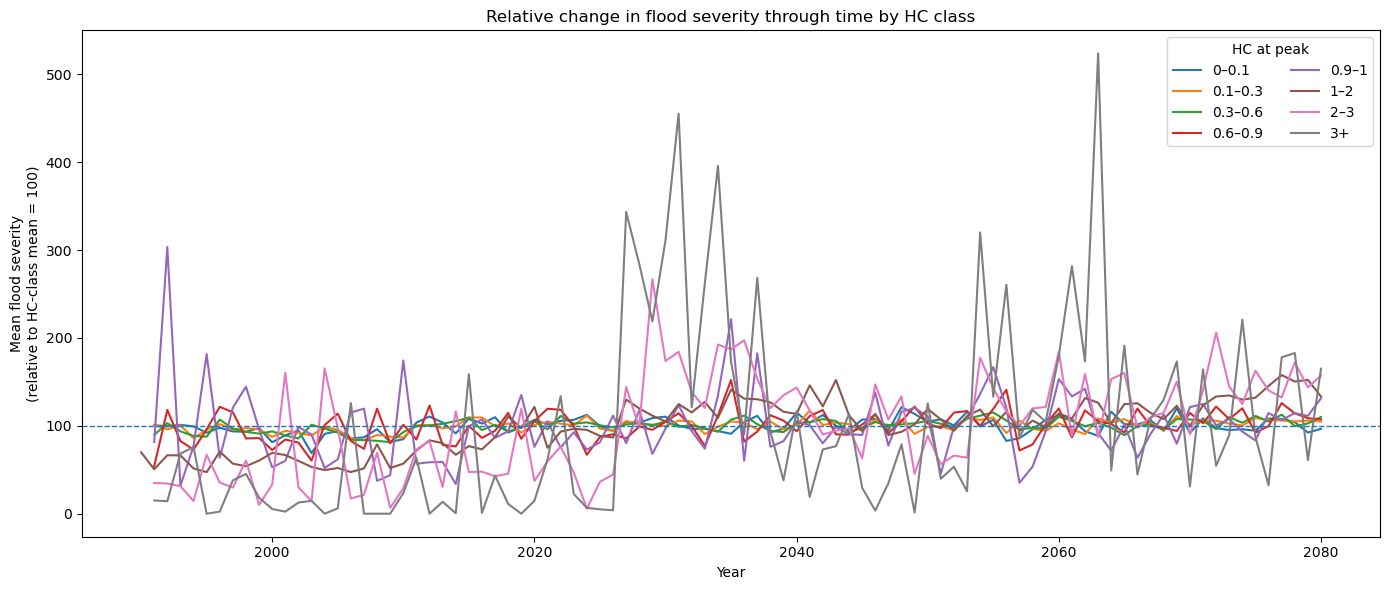

In [18]:
severity_index = (
    annual_mean_severity
    / annual_mean_severity.mean(axis=0)
    * 100
)

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot(
        severity_index.index,
        severity_index[hc],
        label=hc,
        linewidth=1.5
    )

ax.axhline(
    100,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Year")
ax.set_ylabel(
    "Mean flood severity\n"
    "(relative to HC-class mean = 100)"
)

ax.set_title(
    "Relative change in flood severity through time by HC class"
)

ax.legend(
    title="HC at peak",
    ncol=2
)

plt.tight_layout()
plt.show()

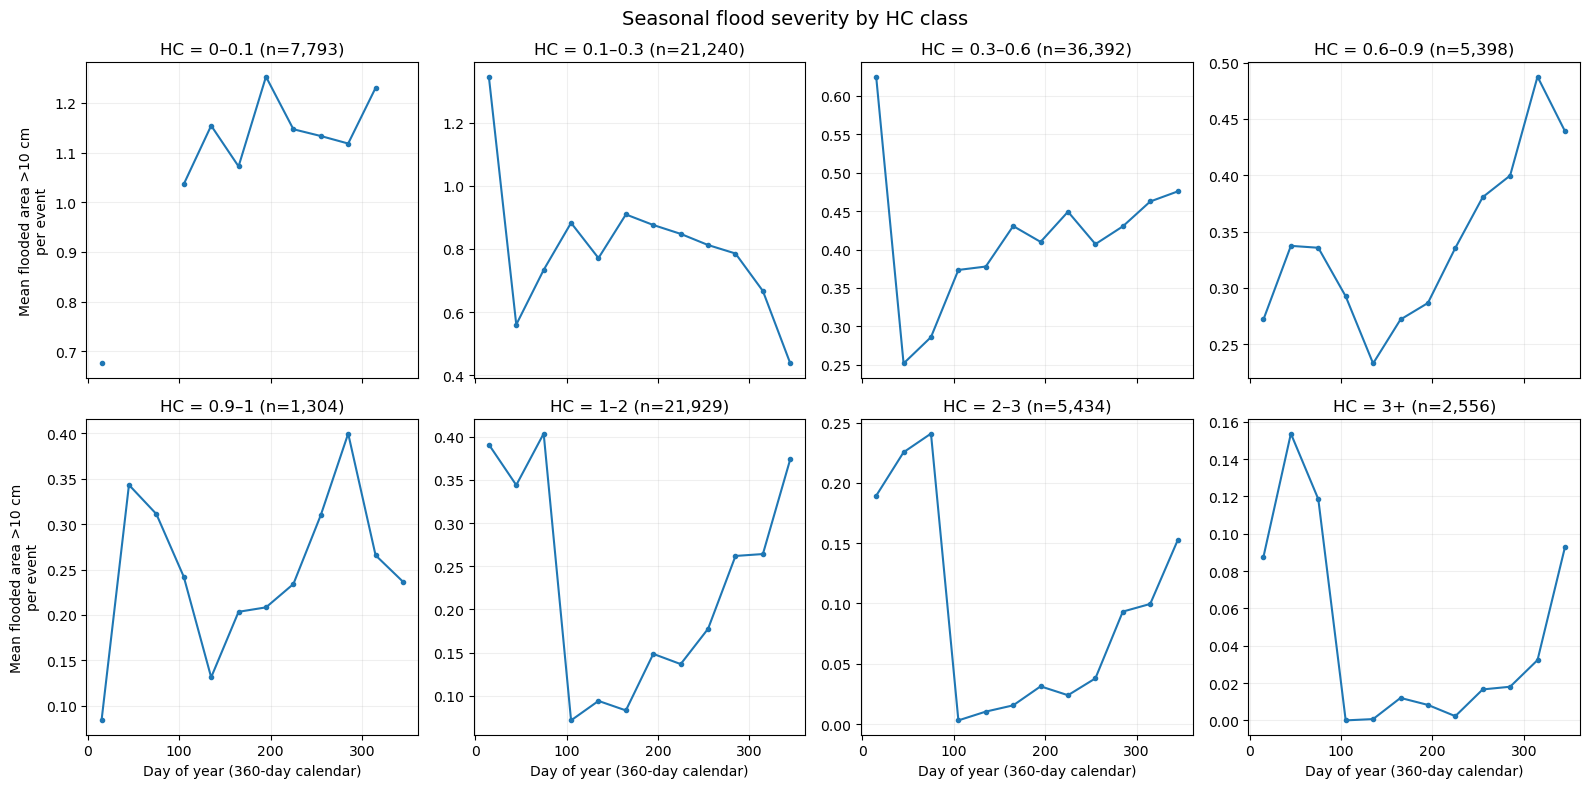

In [20]:
# =========================================================
# Seasonal flood severity
# =========================================================

bin_width = 30

bin_edges = np.arange(
    0,
    360 + bin_width,
    bin_width
)

bin_centers = (
    bin_edges[:-1] + bin_width / 2
)

df["season_bin"] = pd.cut(
    df["day_360"],
    bins=bin_edges,
    labels=bin_centers,
    include_lowest=True
)

# Mean flooded area per event
seasonal_severity = (
    df.groupby(
        ["HC_class", "season_bin"],
        observed=True
    )["10cm_area"]
    .mean()
    .unstack()
)

seasonal_severity = seasonal_severity.reindex(
    index=hc_labels,
    columns=bin_centers
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, hc in zip(axes, hc_labels):

    values = seasonal_severity.loc[hc]

    ax.plot(
        bin_centers,
        values,
        marker="o",
        markersize=3,
        linewidth=1.5
    )

    n = len(df[df["HC_class"] == hc])

    ax.set_title(
        f"HC = {hc} (n={n:,})"
    )

    ax.grid(alpha=0.2)

for ax in axes[4:]:
    ax.set_xlabel(
        "Day of year (360-day calendar)"
    )

for ax in axes[::4]:
    ax.set_ylabel(
        "Mean flooded area >10 cm\nper event"
    )

fig.suptitle(
    "Seasonal flood severity by HC class",
    fontsize=14
)

plt.tight_layout()
plt.show()

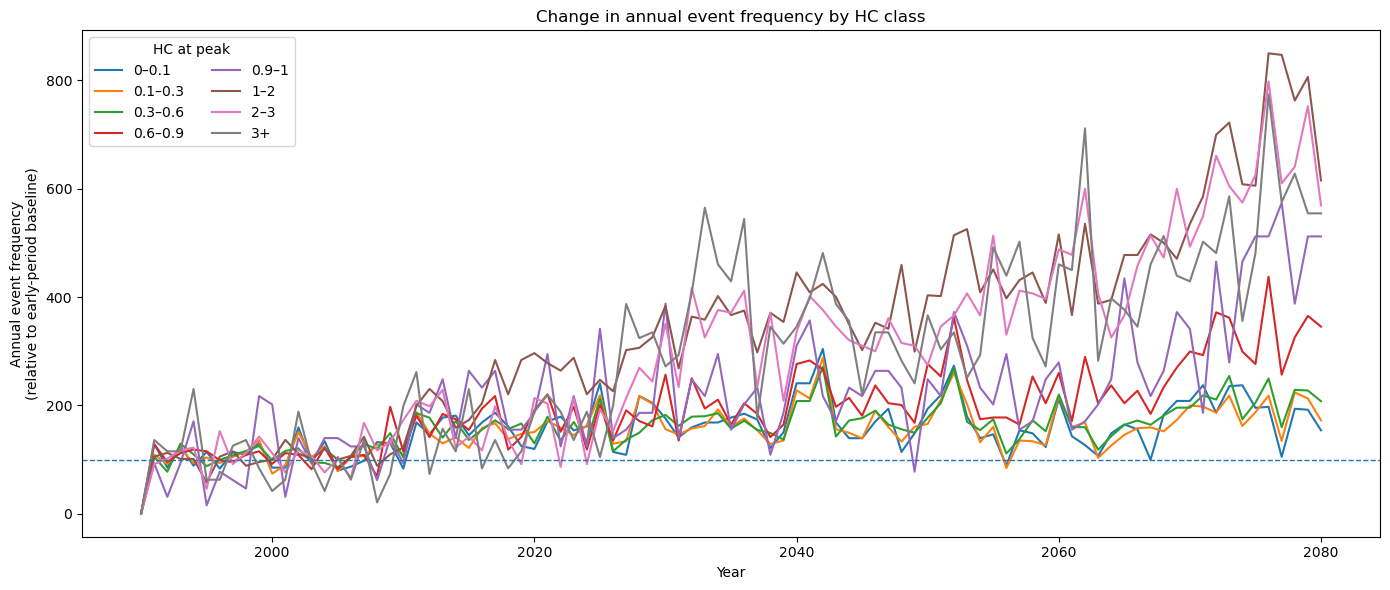

In [4]:
# ---------------------------------------------------------
# Index relative to early-simulation baseline
# ---------------------------------------------------------

years = np.sort(annual_counts.index)

n_baseline = max(1, int(len(years) * 0.2))

baseline_years = years[:n_baseline]

baseline = annual_counts.loc[baseline_years].mean()

annual_index_baseline = ( annual_counts / baseline* 100)

fig, ax = plt.subplots(figsize=(14, 6))

for hc in hc_labels:
    ax.plot( annual_index_baseline.index, annual_index_baseline[hc], label=hc, linewidth=1.5)

# 100 = baseline period
ax.axhline(100,linestyle="--",linewidth=1)

ax.set_xlabel("Year")
ax.set_ylabel("Annual event frequency\n(relative to early-period baseline)")

ax.set_title("Change in annual event frequency by HC class")

ax.legend(title="HC at peak",ncol=2)

plt.tight_layout()
plt.show()

HC_class
0–0.1       78.269618
0.1–0.3     73.920929
0.3–0.6     92.835165
0.6–0.9    188.482633
0.9–1      275.862069
1–2        503.590945
2–3        456.779661
3+         385.465116
dtype: float64


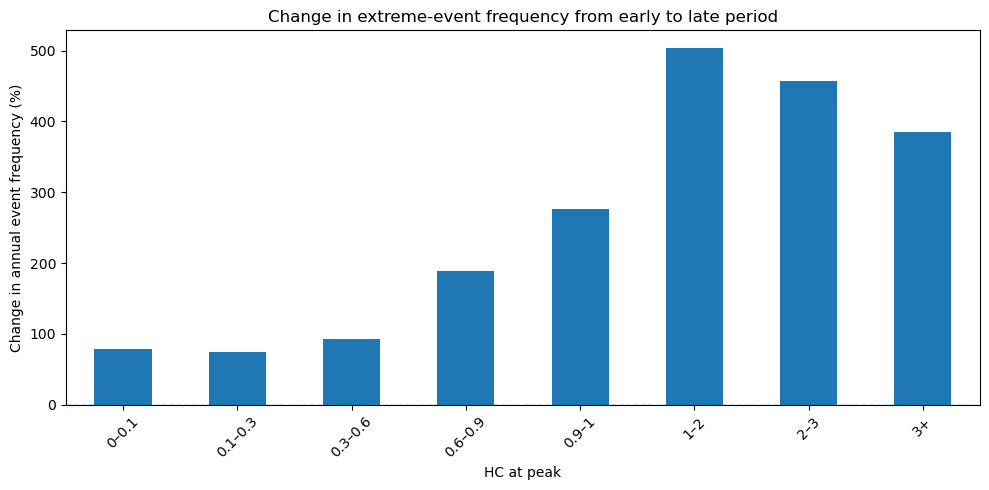

In [11]:
years = np.sort(annual_counts.index)

n_period = max(1, int(len(years) * 0.2))

early_years = years[:n_period]
late_years = years[-n_period:]

early_mean = annual_counts.loc[early_years].mean()
late_mean = annual_counts.loc[late_years].mean()

percentage_change = ((late_mean - early_mean) / early_mean * 100)

print(percentage_change)

fig, ax = plt.subplots(figsize=(10, 5))

percentage_change.plot(kind="bar",ax=ax)

ax.axhline(0,linestyle="--",linewidth=1)

ax.set_xlabel("HC at peak")
ax.set_ylabel("Change in annual event frequency (%)")
ax.set_title("Change in extreme-event frequency from early to late period")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
comparison = pd.DataFrame({
    "early_mean_events_per_year": early_mean,
    "late_mean_events_per_year": late_mean,
    "absolute_change": late_mean - early_mean,
    "percentage_change": percentage_change})

print(comparison)

          early_mean_events_per_year  late_mean_events_per_year  \
HC_class                                                          
0–0.1                      55.222222                  98.444444   
0.1–0.3                   153.166667                 266.388889   
0.3–0.6                   252.777778                 487.444444   
0.6–0.9                    30.388889                  87.666667   
0.9–1                       6.444444                  24.222222   
1–2                        71.166667                 429.555556   
2–3                        19.666667                 109.500000   
3+                          9.555556                  46.388889   

          absolute_change  percentage_change  
HC_class                                      
0–0.1           43.222222          78.269618  
0.1–0.3        113.222222          73.920929  
0.3–0.6        234.666667          92.835165  
0.6–0.9         57.277778         188.482633  
0.9–1           17.777778         275.862069  


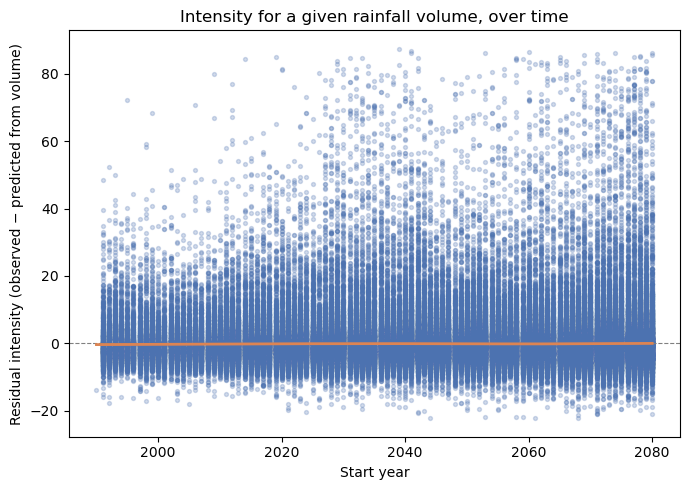

Mann-Kendall (tau=0.016, p=0.0000)


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

df = rainfall_events_all_df.copy()
df['log_acc'] = np.log(df['total_acc'])

# --- 1. fit intensity ~ volume once, pooled across all years ---
sub = df.sort_values('log_acc')
fitted = lowess(sub['max_precip'], sub['log_acc'], frac=0.4, return_sorted=False)
df.loc[sub.index, 'pred_intensity'] = fitted
df['residual_intensity'] = df['max_precip'] - df['pred_intensity']

# --- 2. residual over time ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.scatter(df['start_year'], df['residual_intensity'], s=8, alpha=0.25, color='#4C72B0')

trend = lowess(df['residual_intensity'], df['start_year'], frac=0.5)
ax.plot(trend[:, 0], trend[:, 1], color='#DD8452', lw=2)

ax.set_xlabel('Start year')
ax.set_ylabel('Residual intensity (observed − predicted from volume)')
ax.set_title('Intensity for a given rainfall volume, over time')
plt.tight_layout()
plt.show()

# --- 3. formal trend test on the residual ---
tau, p = stats.kendalltau(df['start_year'], df['residual_intensity'])
print(f"Mann-Kendall (tau={tau:.3f}, p={p:.4f})")

/tmp/ipykernel_638088/2852480131.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (vb, sub) in zip(axes, df.groupby('vol_bin')):


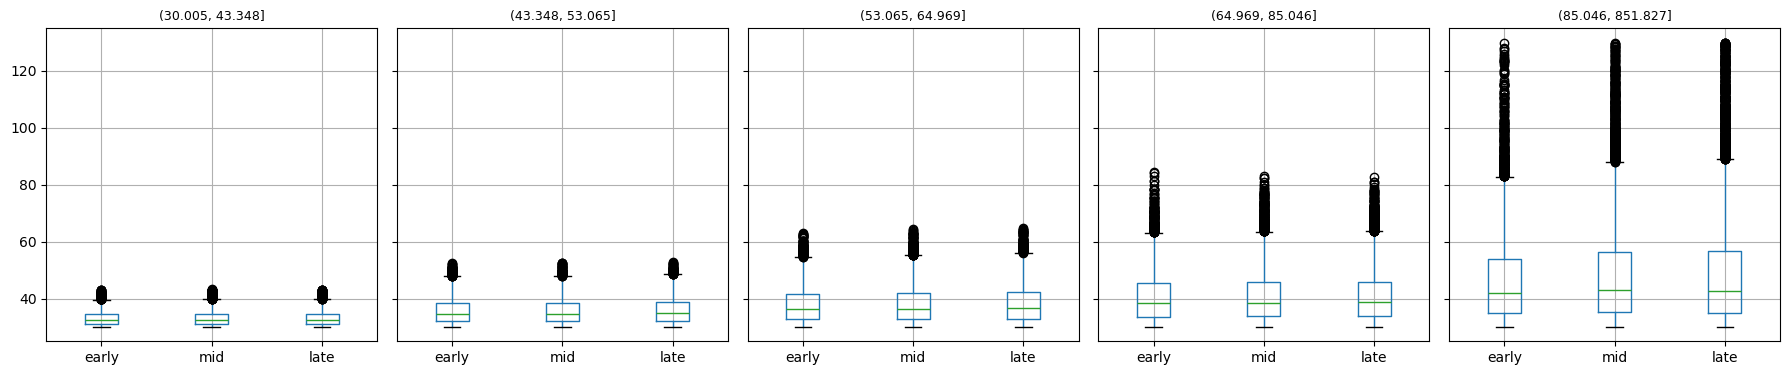

In [14]:
df['vol_bin'] = pd.qcut(df['total_acc'], q=5, duplicates='drop')
df['period'] = pd.qcut(df['start_year'], q=3, labels=['early','mid','late'])

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for ax, (vb, sub) in zip(axes, df.groupby('vol_bin')):
    sub.boxplot(column='max_precip', by='period', ax=ax)
    ax.set_title(f'{vb}', fontsize=9)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()